# مختبر عبور الكواكب — Proof of Concept

هذا الدفتر هو الجسر بين ملفات **FITS** الخام وتجربة الـ **Discovery Webapp**. هو لا يدّعي اكتشاف كوكب جديد؛ بل يوضح كيف نحدد النجم المضيف، نقيس سطوعه عبر الزمن، نرفض الإطارات الرديئة، ثم نشرح للمستخدم لماذا تكفي البيانات أو لا تكفي.

> الفكرة البصرية الصحيحة: الكوكب نفسه غير ظاهر في الصورة. نرى النجم ونبحث عن انخفاض صغير ومنتظم في ضوئه وقت مرور الكوكب أمامه.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display, Markdown, Image
import ipywidgets as widgets

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'outputs').exists(), f'Project root not found from {Path.cwd()}'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.2})
print('Project:', ROOT)

Project: C:\Users\iix_m\Downloads\hack4dev


## 1) ماذا أنجز الـ pipeline؟

1. بنى **Master Dark** من إطارات المعايرة وطرحه من صور السماء.
2. اختار أفضل إطار مرجعي بدل افتراض أن أول صورة هي الأفضل.
3. حلّ موقع السماء بـ **Astrometry.net**، ثم ربط النجوم بفهرس **Gaia**.
4. ثبّت WASP والنـجوم المقارنة وتتبع انجراف المجال بين الصور.
5. نفّذ aperture photometry وقسّم سطوع الهدف على مجموعة نجوم مقارنة.
6. حوّل الوقت إلى BJD_TDB، وقارن القياسات بنافذة العبور المنشورة.
7. صدّر PNG وCSV وJSON خفيفة يستطيع الموقع استهلاكها دون تحميل 1.1 GB من FITS.

In [2]:
RUNS = {
    'WASP-10 — 2026-08-08': ROOT / 'outputs/wasp_10/2026-08-08',
    'WASP-2 — 2026-08-11': ROOT / 'outputs/wasp_2/2026-08-11',
    'WASP-2 — 2026-08-24': ROOT / 'outputs/wasp_2/2026-08-24',
}
summaries = []
for label, folder in RUNS.items():
    item = json.loads((folder / 'summary.json').read_text(encoding='utf-8'))
    summaries.append({
        'الجلسة': label,
        'المقبول / الكل': f"{item['accepted_frames']} / {item['total_frames']}",
        'قبل / داخل / بعد': f"{item['pre_transit_points']} / {item['in_transit_points']} / {item['post_transit_points']}",
        'التشتت %': round(item['residual_scatter_percent'], 3),
        'عمق منشور %': item['published_depth_percent'],
        'الحكم': 'غير كافٍ لإثبات العبور' if not item['fit_valid'] else 'مرشح أولي',
    })
display(pd.DataFrame(summaries).style.hide(axis='index'))

الجلسة,المقبول / الكل,قبل / داخل / بعد,التشتت %,عمق منشور %,الحكم
WASP-10 — 2026-08-08,31 / 86,4 / 27 / 0,4.276000,2.525000,غير كافٍ لإثبات العبور
WASP-2 — 2026-08-11,22 / 78,0 / 22 / 0,0.855000,1.646000,غير كافٍ لإثبات العبور
WASP-2 — 2026-08-24,40 / 77,0 / 9 / 31,9.468000,1.646000,غير كافٍ لإثبات العبور


## 2) الدليل والقيود في نظرة واحدة

الدائرة الصفراء هي **النجم المضيف** بعد حل الإحداثيات، والدوائر الزرقاء نجوم Gaia للمقارنة وليست كواكب. الرسم الثاني هو القياس الزمني؛ العلامات الرمادية تمثل إطارات رفضناها ولا نسمح لها بتشويه مقياس المحور. الرسم الثالث يبرر الرفض عبر انجراف المجال وضوضاء الخلفية واستقرار نجوم المقارنة.

### WASP-10 — 2026-08-08

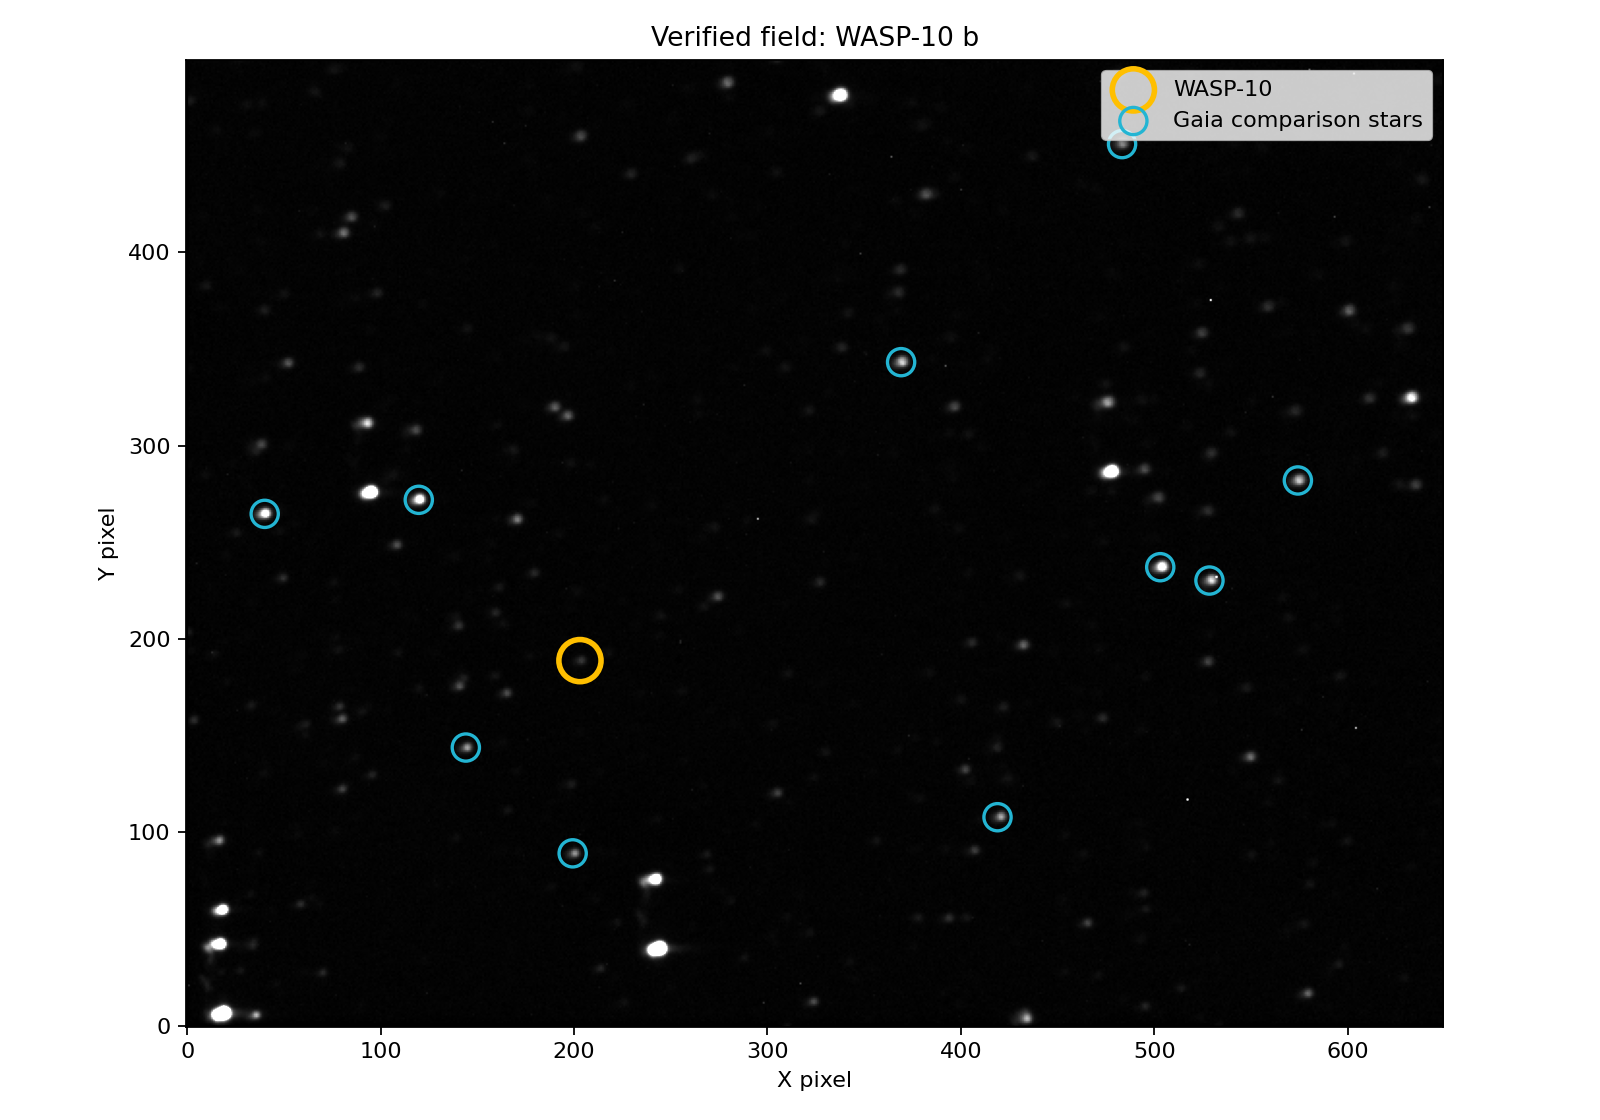

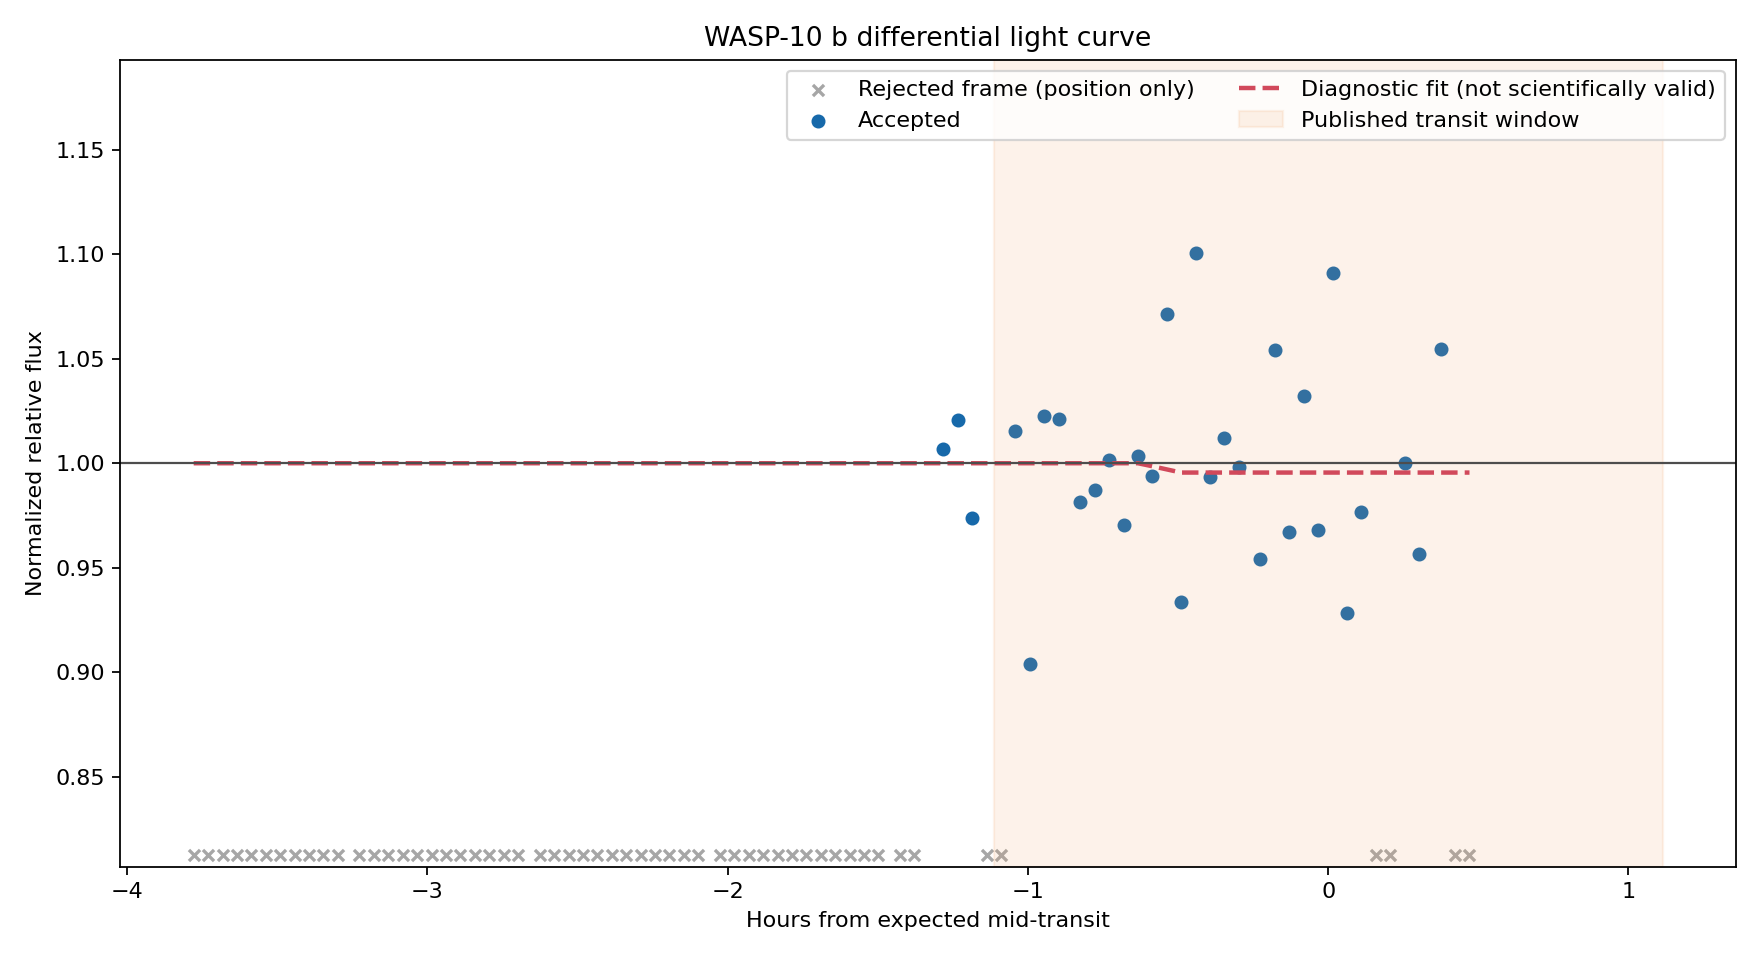

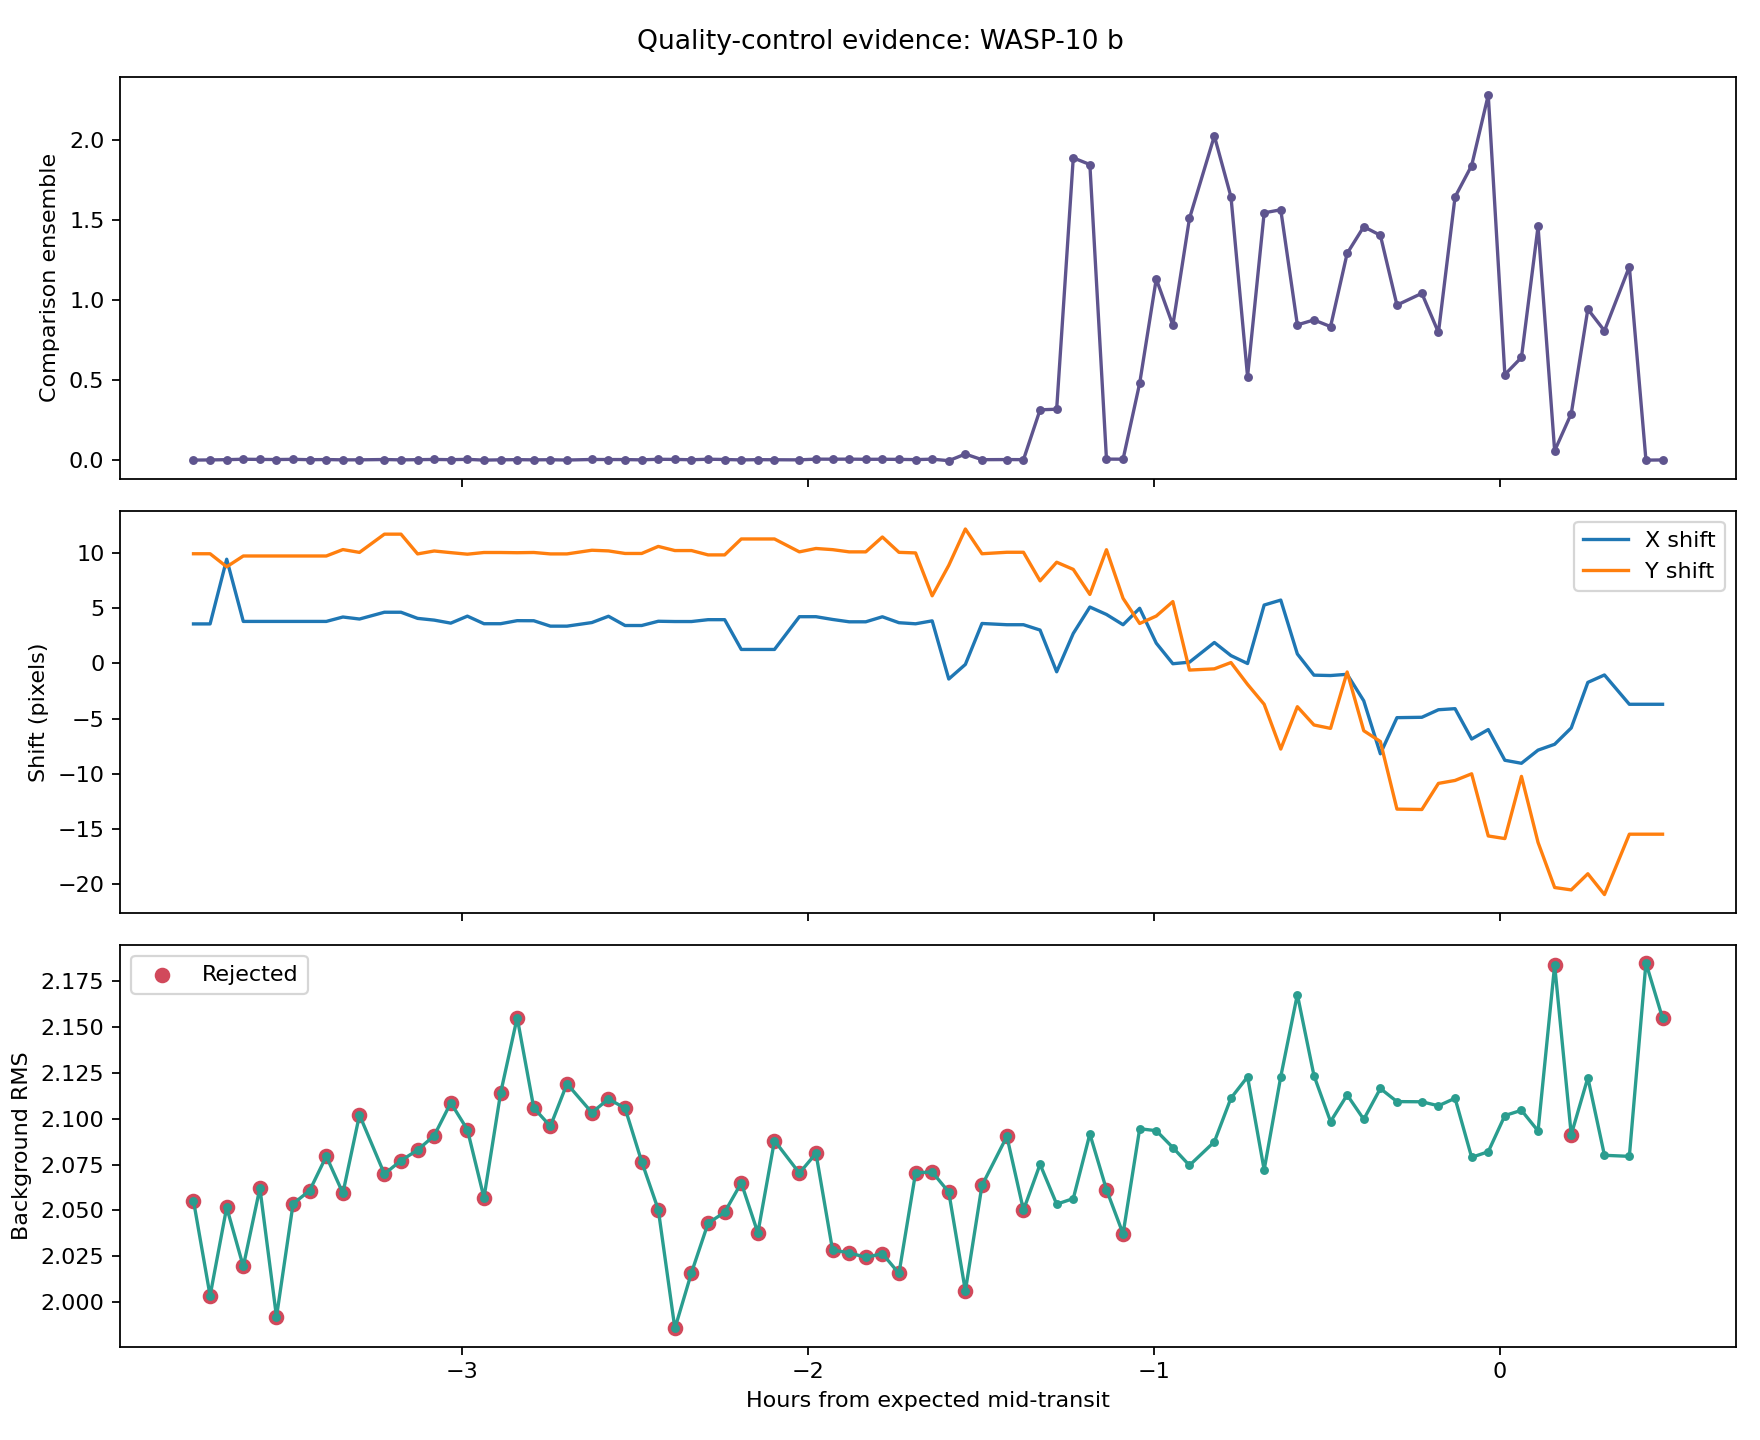

### WASP-2 — 2026-08-11

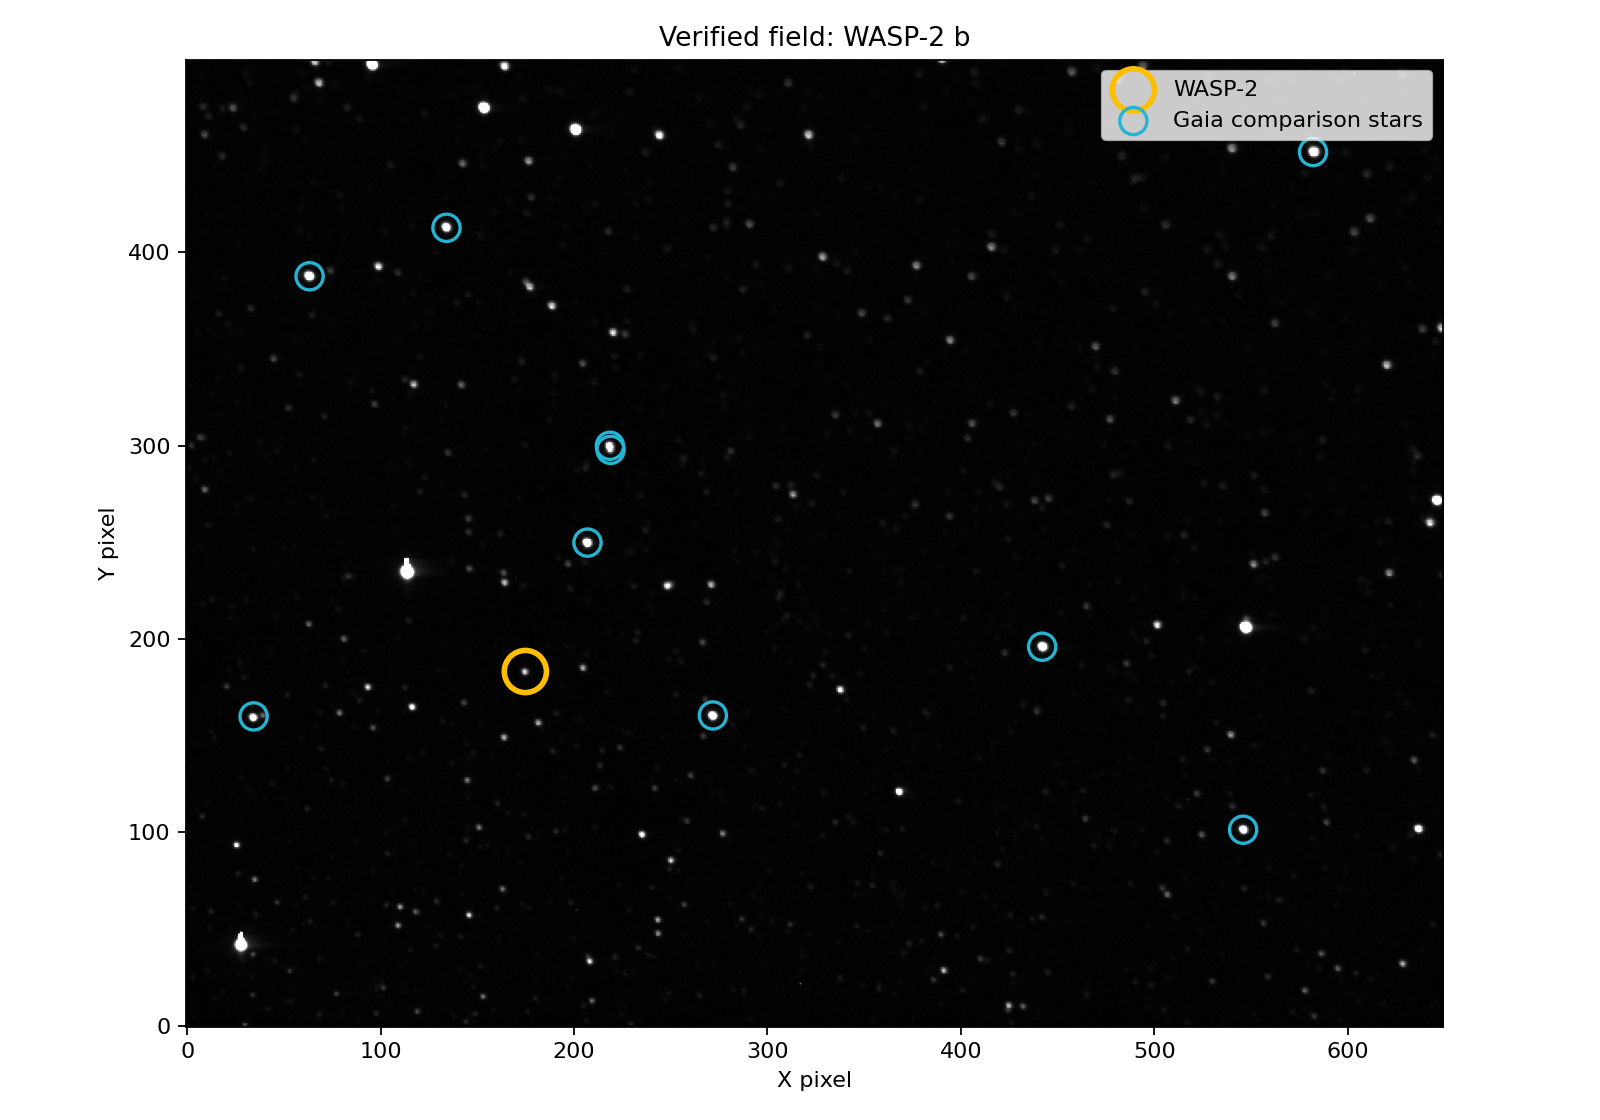

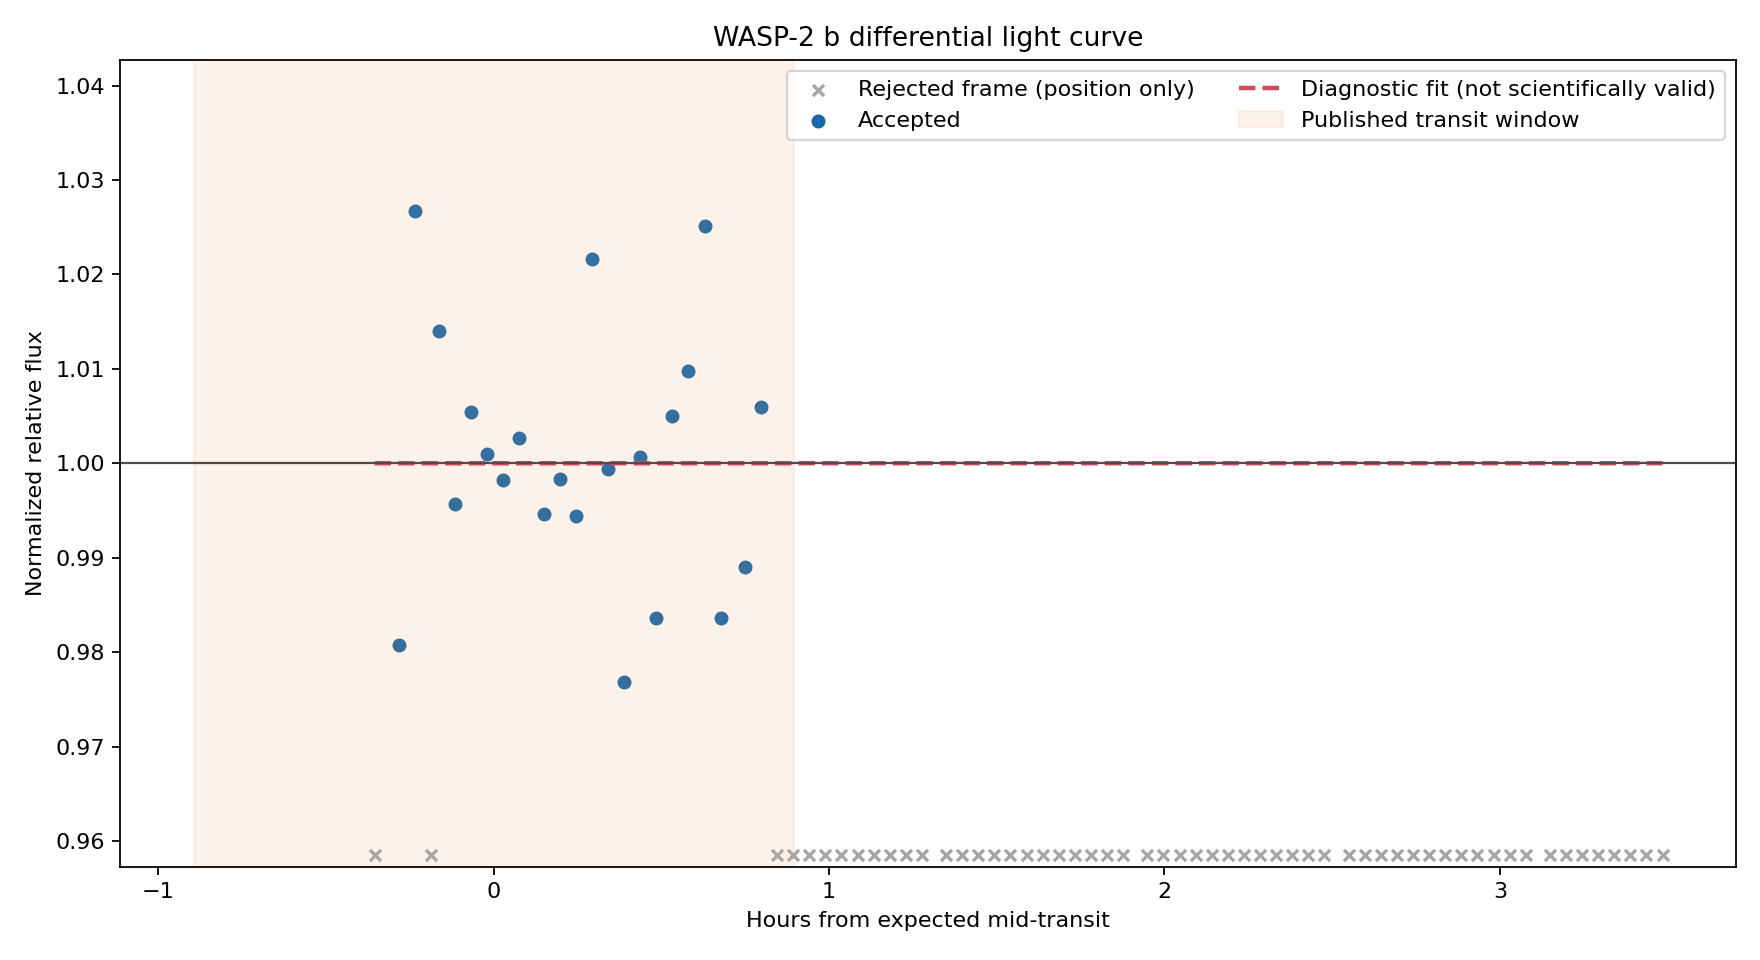

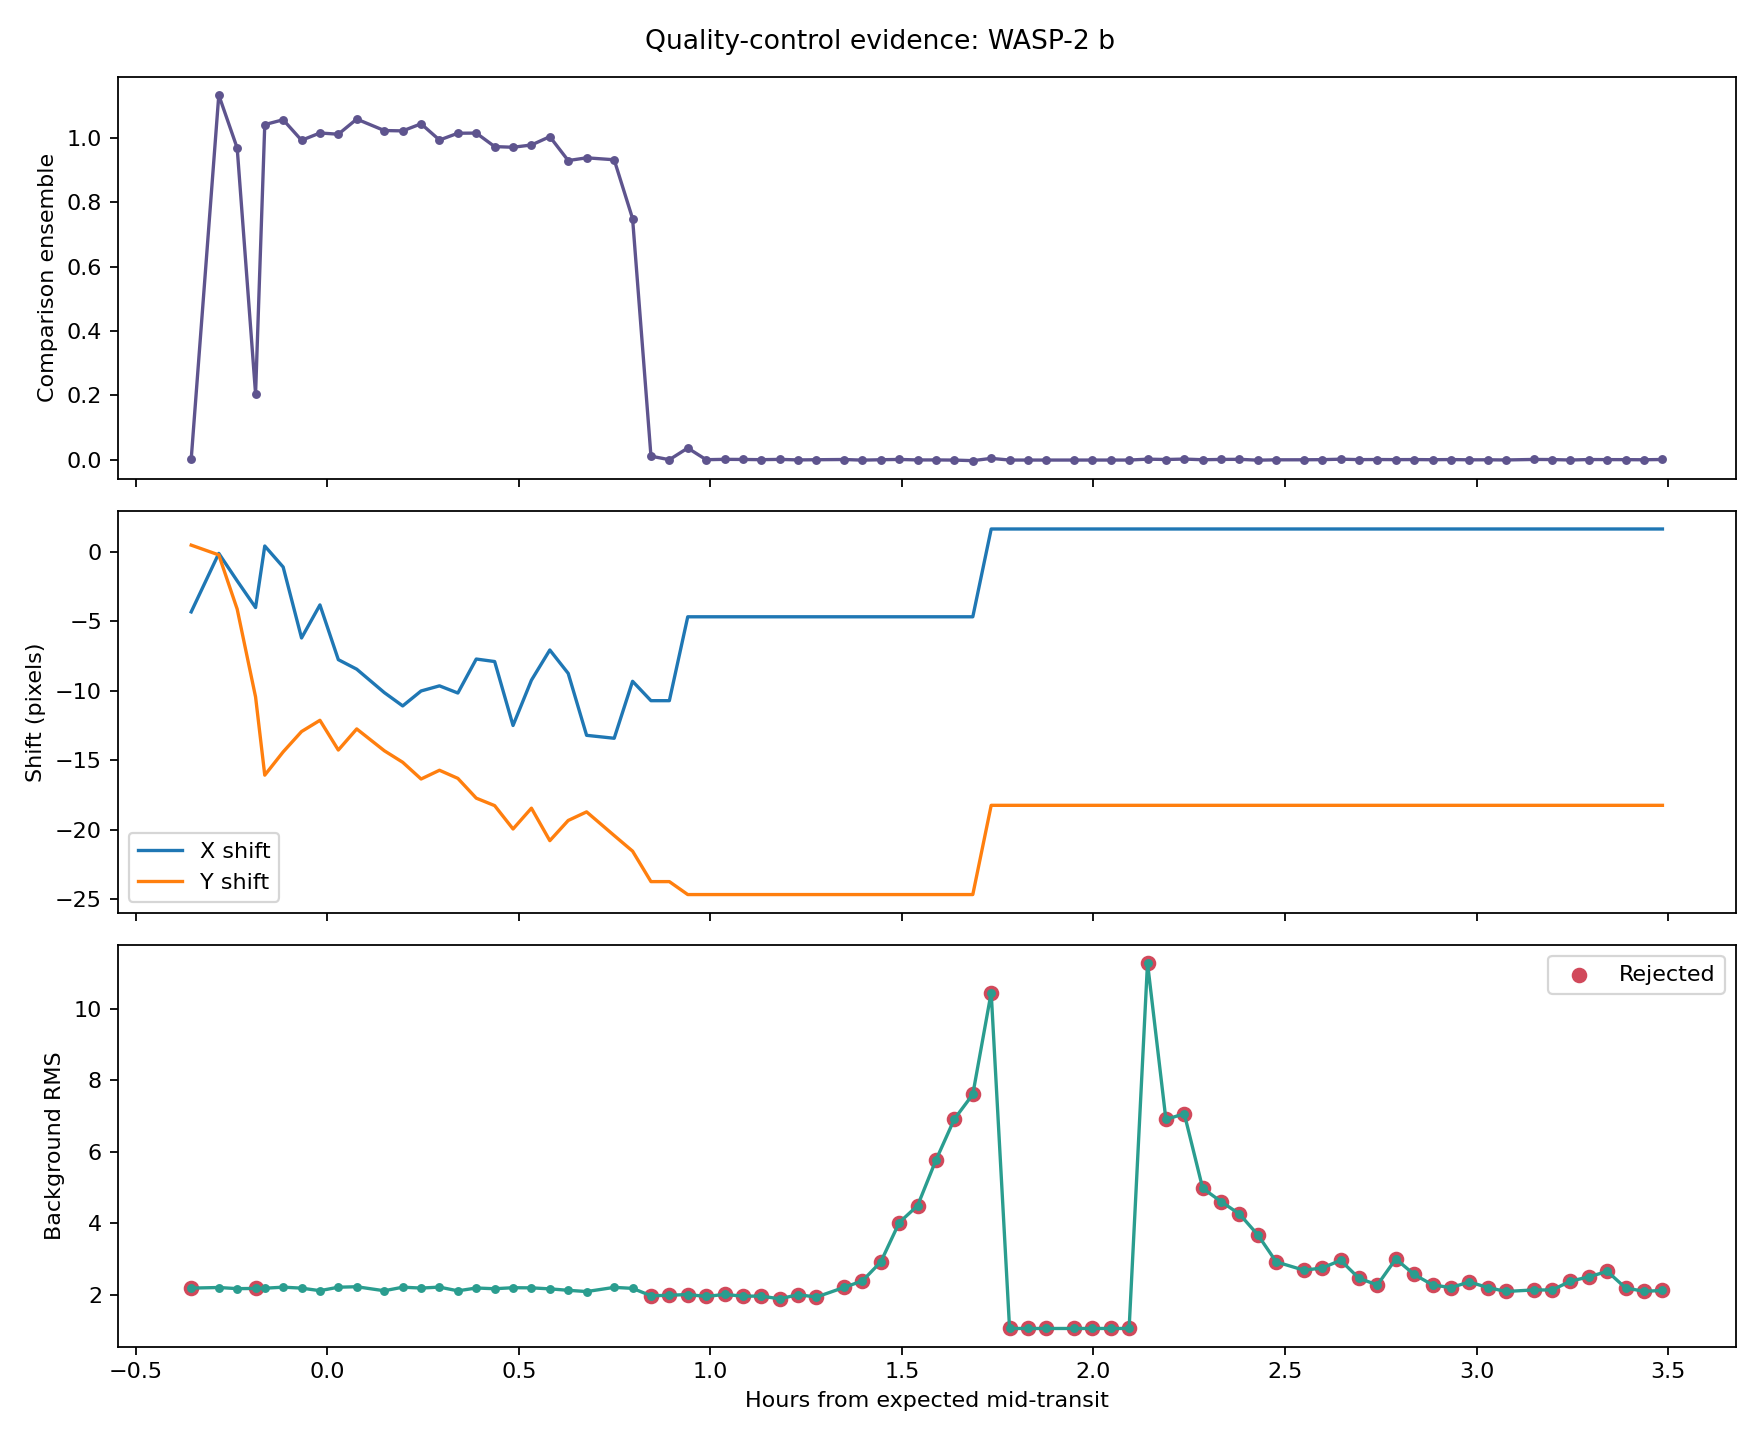

In [3]:
for label in ['WASP-10 — 2026-08-08', 'WASP-2 — 2026-08-11']:
    display(Markdown(f'### {label}'))
    folder = RUNS[label]
    for filename in ['01_verified_field.png', '02_light_curve.png', '03_quality_control.png']:
        display(Image(filename=str(folder / filename), width=900))

## 3) مستكشف الإطارات التفاعلي

اختر الجلسة ثم حرّك المنزلق. على اليسار ترى صورة FITS بخريطة تباين مناسبة مع موضع WASP المتتبّع؛ وعلى اليمين ترى النقطة الزمنية نفسها. **Accepted** تعني أن الإطار اجتاز قواعد الجودة، لا أنه أثبت وجود الكوكب.

In [4]:
SESSION_INPUTS = {
    'WASP-10 — 2026-08-08': (ROOT / 'database/observations/2026-08-08/WASP-10/session_01', ROOT / 'database/calibration/2026-08-08'),
    'WASP-2 — 2026-08-11': (ROOT / 'database/observations/2026-08-11/WASP-2/session_01', ROOT / 'database/calibration/2026-08-11'),
    'WASP-2 — 2026-08-24': (ROOT / 'database/observations/2026-08-24/WASP-2/session_01', ROOT / 'database/calibration/2026-08-24'),
}
_cache = {}

def load_session(label):
    if label not in _cache:
        out = RUNS[label]
        science_dir, dark_dir = SESSION_INPUTS[label]
        table = pd.read_csv(out / 'photometry.csv')
        summary = json.loads((out / 'summary.json').read_text(encoding='utf-8'))
        darks = [fits.getdata(p).astype('float32') for p in sorted(dark_dir.glob('*.fits'))]
        _cache[label] = (table, summary, science_dir, np.nanmedian(darks, axis=0))
    return _cache[label]

def show_frame(label, frame):
    table, summary, science_dir, master_dark = load_session(label)
    i = min(frame, len(table) - 1)
    row = table.iloc[i]
    image = fits.getdata(science_dir / row.file_name).astype('float32') - master_dark
    image = image - np.nanmedian(image)
    lo, hi = np.nanpercentile(image, [5, 99.8])
    target_x = summary['target_x_reference'] + row.shift_x
    target_y = summary['target_y_reference'] + row.shift_y
    good = table.accepted.astype(bool).to_numpy()
    accepted_flux = table.loc[good, 'detrended_flux'].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    center = np.median(accepted_flux)
    mad_sigma = 1.4826 * np.median(np.abs(accepted_flux - center))
    half_range = min(max(5 * mad_sigma, 0.03), 0.25)
    y0, y1 = center - half_range, center + half_range

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    axes[0].imshow(image, origin='lower', cmap='gray', vmin=lo, vmax=hi)
    axes[0].scatter(target_x, target_y, s=260, facecolors='none', edgecolors='#ffbf00', linewidths=2.3)
    axes[0].set(title=f"Frame {i}: {row.file_name}\nWASP host — {'Accepted' if row.accepted else 'Rejected'}", xlabel='X pixel', ylabel='Y pixel')

    axes[1].scatter(table.loc[good, 'hours_from_expected_mid'], table.loc[good, 'detrended_flux'], s=22, color='#1769aa', label='Accepted')
    half = json.loads((ROOT / 'config/targets.json').read_text())[summary['target']]['duration_hours'] / 2
    axes[1].axvspan(-half, half, color='#f4a261', alpha=0.13, label='Published window')
    if bool(row.accepted) and np.isfinite(row.detrended_flux):
        axes[1].scatter(row.hours_from_expected_mid, row.detrended_flux, s=170, facecolors='none', edgecolors='#ffbf00', linewidths=2.5, label='This frame')
    else:
        axes[1].scatter(row.hours_from_expected_mid, y0 + 0.02*(y1-y0), marker='x', s=90, color='#d1495b', label='This frame: rejected')
    axes[1].axhline(1, color='0.3', linewidth=1)
    axes[1].set_ylim(y0, y1)
    axes[1].set(title='The same frame on the light curve', xlabel='Hours from expected mid-transit', ylabel='Normalized relative flux')
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    plt.show()

session_picker = widgets.Dropdown(options=list(RUNS), description='Session:', layout=widgets.Layout(width='420px'))
frame_slider = widgets.IntSlider(value=0, min=0, max=85, step=1, description='Frame:', continuous_update=False, layout=widgets.Layout(width='650px'))
def sync_slider(change):
    frame_slider.max = len(load_session(change['new'])[0]) - 1
    frame_slider.value = min(frame_slider.value, frame_slider.max)
session_picker.observe(sync_slider, names='value')
sync_slider({'new': session_picker.value})
interactive_view = widgets.interactive_output(show_frame, {'label': session_picker, 'frame': frame_slider})
display(session_picker, frame_slider, interactive_view)

Dropdown(description='Session:', layout=Layout(width='420px'), options=('WASP-10 — 2026-08-08', 'WASP-2 — 2026…

IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='650px'), max=85)

Output()

## 4) النقد كحَكَم أو فلكي

- **ما نجح:** تعيين الحقل لم يعد تخمينًا؛ Astrometry.net يحدد نظام الإحداثيات وGaia يثبت الهدف ونجوم المقارنة. المسار قابل للإعادة ويصدر ملفات مناسبة للويب.
- **ما لم ينجح علميًا بعد:** لا توجد لأي جلسة معروضة نقاط كافية قبل العبور وداخله وبعده معًا. لذلك قيم العمق الملائمة هنا تشخيصية فقط ولا يجوز مقارنتها بالعمق المنشور كقياس مكتمل.
- **جودة المعايرة:** لدينا Dark frames قليلة، ولا توجد Flats أو Bias ظاهرة في البيانات؛ هذا يترك أخطاء حساسية البكسلات والتظليل دون تصحيح كامل.
- **WASP-10:** 31/86 إطارًا مقبولًا، التشتت 4.28% أكبر من إشارة العبور المنشورة 2.525%، ولا توجد نقاط مقبولة بعد العبور.
- **WASP-2 (11 أغسطس):** أنظف نسبيًا (0.855%) لكن النقاط المقبولة كلها داخل النافذة المتوقعة تقريبًا، فلا يوجد baseline يقيس الانخفاض بالنسبة إليه.
- **WASP-2 (24 أغسطس):** توجد نقاط بعد النافذة، لكن التشتت 9.47% يجعل الملاءمة غير موثوقة.

**الحكم الصادق:** الـPOC يثبت إمكان بناء أداة اكتشاف/شرح وفحص جودة، لكنه لا يثبت عبورًا من هذه الجلسات الثلاث. الخطوة العلمية التالية هي تشغيل الأنظمة والجلسات الأخرى آليًا، اختيار جلسة ذات تغطية كاملة وتشتت أقل، ثم التحقق المستقل بـ EXOTIC.

## إعادة بناء النتائج

من Terminal داخل مجلد المشروع:

```powershell
.\run_poc.ps1 --cached-only
```

يحمي خيار `--cached-only` التشغيل من إرسال plate-solve جديد إلى الإنترنت ويستخدم حلول WCS المحفوظة. لحالة جديدة تحتاج أول مرة إلى الإنترنت، شغّل الهدف والتاريخ دون هذا الخيار.